<a href="https://colab.research.google.com/github/EthanFerba/IDX-Exchange-Data-Science/blob/main/EDA_Phase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [123]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import plotly.express as px
plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)
pd.set_option("display.float_format", lambda x: "%.2f" % x)

Just build the basic libraires that I will need to pre-process

In [124]:
df22_23 = pd.read_csv('/content/CRMLSSold20220101_20231231_filled(first 2 years).csv')
df24 = pd.read_csv('/content/CRMLSSold202401_filled(january_2024).csv')

/tmp/ipykernel_1760/819583140.py:1: DtypeWarning:

Columns (78,79) have mixed types. Specify dtype option on import or set low_memory=False.



In [125]:
mdf = pd.concat([df22_23, df24], ignore_index=True)


In [126]:
mdf.head()

,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,PropertyType,LivingArea,ListPrice,DaysOnMarket,ListOfficeName,BuyerOfficeName,CoListOfficeName,ListAgentFullName,CoListAgentFirstName,CoListAgentLastName,BuyerAgentMlsId,BuyerAgentFirstName,BuyerAgentLastName,FireplacesTotal,AssociationFeeFrequency,AboveGradeFinishedArea,ListingKeyNumeric,MLSAreaMajor,TaxAnnualAmount,CountyOrParish,MlsStatus,ElementarySchool,AttachedGarageYN,ParkingTotal,BuilderName,PropertySubType,LotSizeAcres,SubdivisionName,BuyerOfficeAOR,YearBuilt,BuyerAgencyCompensationType,StreetNumberNumeric,ListingId,BathroomsTotalInteger,City,BuyerAgencyCompensation,TaxYear,BuildingAreaTotal,BedroomsTotal,ContractStatusChangeDate,ElementarySchoolDistrict,CoBuyerAgentFirstName,PurchaseContractDate,ListingContractDate,BelowGradeFinishedArea,BusinessType,StateOrProvince,CoveredSpaces,MiddleOrJuniorSchool,FireplaceYN,Stories,HighSchool,Levels,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled
0,"Carpet,Wood",True,NaN,NaN,True,98000.00,556366533,michellefsellsoc@gmail.com,2022-02-25,95000.00,Michelle,Fairchild,33.70,-117.96,231 Albatross Lane,ManufacturedInPark,1368.00,98000.00,86.00,Premiere Choice R E Inc,Premiere Choice R E Inc,Premiere Choice R E Inc,Michelle Fairchild,Josh,Lukasiewicz,ocfairmic,Michelle,Fairchild,NaN,NaN,NaN,556366533.00,16 - Fountain Valley / Northeast HB,NaN,Orange,Closed,NaN,NaN,2.00,NaN,NaN,NaN,Rancho la Siesta 55+ Senior,OrangeCounty,1969.00,Item,231.00,OC21227682,2.00,Fountain Valley,1500.00,NaN,NaN,2.00,2022-02-25,NaN,NaN,2022-01-28,2021-10-13,NaN,NaN,CA,NaN,NaN,NaN,1.00,NaN,One,NaN,NaN,NaN,NaN,0.00,ABC Unified,92708,0.00,NaN,NaN,False,False
1,NaN,False,NaN,NaN,False,1200.00,556366530,dineshcalre@gmail.com,2022-02-19,1200.00,DINESH,MAYANI,34.50,-117.19,21601 Powhatan Road 2,ResidentialLease,850.00,1200.00,125.00,California Real Estate & Investments,California Real Estate & Investments,NaN,DINESH MAYANI,NaN,NaN,evmayadin,DINESH,MAYANI,NaN,NaN,NaN,556366530.00,APPV - Apple Valley,NaN,San Bernardino,Closed,NaN,False,1.00,NaN,Apartment,0.99,NaN,EastValley,1987.00,Item,21601.00,EV21227683,1.00,Apple Valley,100.00,NaN,NaN,2.00,2022-02-19,NaN,NaN,2022-02-19,2021-10-13,NaN,NaN,CA,NaN,NaN,False,1.00,NaN,One,NaN,43000.00,2.00,False,1.00,Apple Valley Unified,92308,0.00,43000.00,NaN,False,False
2,NaN,True,NaN,NaN,False,1100000.00,556366044,cindydavishomes@gmail.com,2022-04-15,1100000.00,Cindy,Davis,32.98,-117.26,827 Del Mar Downs Rd. D,Residential,1344.00,1100000.00,106.00,SD Home Source Realty,Compass,NaN,Cindy Davis,NaN,NaN,SAND-646850,Lindsay,Dunlap,NaN,Monthly,NaN,556366044.00,92075 - Solana Beach,NaN,San Diego,Closed,NaN,True,2.00,NaN,Townhouse,NaN,NaN,SanDiego,1974.00,Item1,827.00,NDP2111697,3.00,Solana Beach,1.50,NaN,NaN,3.00,2022-04-15,NaN,NaN,2022-02-03,2021-10-13,NaN,NaN,CA,NaN,NaN,True,2.00,NaN,Two,NaN,NaN,0.00,NaN,1.00,Solana Beach,92075,370.00,NaN,NaN,False,False
3,NaN,True,NaN,NaN,False,2499999.00,556365765,bryanmeathe@gmail.com,2022-01-04,2499999.00,Bryan,Meathe,33.15,-117.34,295 Chinquapin Ave,Residential,2645.00,2499999.00,37.00,Coldwell Banker Realty,ERA Ranch & Sea Realty,NaN,Bryan Meathe,NaN,NaN,101046,Bill,Kellaway,NaN,Monthly,NaN,556365765.00,92008 - Carlsbad,NaN,San Diego,Closed,NaN,True,2.00,NaN,SingleFamilyResidence,0.31,NaN,NorthSanDiegoCounty,2016.00,Item1,295.00,NDP2111696,4.00,Carlsbad,2.25,NaN,NaN,4.00,2022-01-04,NaN,NaN,2021-11-19,2021-10-13,NaN,NaN,CA,NaN,NaN,False,NaN,NaN,ThreeOrMore,NaN,13376.00,0.00,NaN,2.00,Carlsbad Unified,92008,140.00,13376.00,NaN,False,False
4,"Carpet,Tile",NaN,NaN,NaN,NaN,598888.00,556365290,steven@westsideres.com,2022-01-12,640000.00,Steven,Larson,37.30,-121.84,NaN,Residential,1198.00,598888.00,15.00,Westside Real Estate Se

Next we would want to load in the data that we are going to use. during this step I went and merged the two data sets together. I did this because one sources covers the full years of 2022 and 2023 and the other one covers january 2024. I think in total it would give a great general outlook of the potenital fluxuation of the DV overtime and through different seasons.

In [127]:
mdf.shape

(175786, 80)

In [128]:
mdf.describe()

,OriginalListPrice,ListingKey,ClosePrice,Latitude,Longitude,LivingArea,ListPrice,DaysOnMarket,FireplacesTotal,AboveGradeFinishedArea,ListingKeyNumeric,TaxAnnualAmount,ParkingTotal,LotSizeAcres,YearBuilt,StreetNumberNumeric,BathroomsTotalInteger,BuyerAgencyCompensation,TaxYear,BuildingAreaTotal,BedroomsTotal,ElementarySchoolDistrict,BelowGradeFinishedArea,CoveredSpaces,Stories,LotSizeArea,MainLevelBedrooms,GarageSpaces,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
count,175216.00,175786.00,175784.00,175449.00,175452.00,161204.00,175503.00,175785.00,0.00,0.00,175785.00,805.00,157934.00,158060.00,166540.00,174663.00,165403.00,175673.00,123.00,21278.00,161814.00,0.00,569.00,0.00,129872.00,158864.00,89258.00,151855.00,118595.00,158599.00,0.00
mean,863526.52,1001541747.42,797526.27,34.65,-118.59,13093.57,796478.57,39.88,NaN,NaN,1001541552.79,1254131.87,18.19,74.85,1977.22,23394.58,2.41,159.45,1939.20,2696.09,3.06,NaN,9891557.08,NaN,1.37,56738.45,1.93,1.79,167.04,693961.99,NaN
std,5877599.67,139131698.08,1683585.21,2.15,2.82,3202100.28,1389326.31,94.63,NaN,NaN,139132069.90,35244961.84,3503.05,7250.48,26.57,2196919.28,1.23,1910.05,396.69,8951.96,1.24,NaN,235945692.05,NaN,0.48,2488800.59,1.68,5.09,1227.55,97793293.14,NaN
min,0.00,421448934.00,0.00,-117.45,-156.45,0.00,0.00,-129.00,NaN,NaN,421448934.00,0.00,-46.00,0.00,1776.00,0.00,0.00,0.00,20.00,0.00,0.00,NaN,0.00,NaN,1.00,0.00,0.00,0.00,0.00,0.00,NaN
25%,44522.50,1037835423.25,35437.50,33.74,-118.76,1176.00,42000.00,7.00,NaN,NaN,1037835424.00,170.00,2.00,0.12,1959.00,790.00,2.00,2.00,2020.00,1176.00,2.00,NaN,0.00,NaN,1.00,4815.00,1.00,1.00,0.00,5100.00,NaN
50%,599000.00,1040602172.50,600000.00,34.05,-118.08,1568.00,599000.00,16.00,NaN,NaN,1040602173.00,4592.00,2.00,0.17,1978.00,2751.00,2.00,2.50,2022.00,1690.00,3.00,NaN,0.00,NaN,1.00,7000.00,2.00,2.00,0.00,7234.00,NaN
75%,995000.00,1045566501.50,1000000.00,34.51,-117.34,2128.00,995000.00,41.00,NaN,NaN,1045566502.00,15400.00,2.50,0.29,1998.00,10721.00,3.00,2.50,2022.00,2616.00,4.00,NaN,0.00,NaN,2.00,11326.00,3.00,2.00,270.00,12697.00,NaN
max,965000000.00,1067652762.00,417255000.00,564.00,151.08,909099090.00,245000000.00,4250.00,NaN,NaN,1067652762.00,999999999.00,808885.00,1867743.00,2024.00,650191015.00,44.00,100000.00,2023.00,651289.00,56.00,NaN,5628182881.00,NaN,2.00,449277840.00,255.00,600.00,404000.00,36677520892.00,NaN


In [129]:
mdf.columns

Index(['Flooring', 'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN',
       'OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName',
       'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency',
       'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor',
       'TaxAnnualAmount', 'CountyOrParish', 'MlsStatus', 'ElementarySchool',
       'AttachedGarageYN', 'ParkingTotal', 'BuilderName', 'PropertySubType',
       'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt',
       'BuyerAgencyCompensationType', 'StreetNumberNumeric', 'ListingId',
       'BathroomsTotalInteger', 'City', 'Bu

After taking a look at the orginal columns, there are a lot that might not add a lot of value into analysis which means we can exclude them. (I think towards the end we can look back at these different feilds and add them back in just to see if there is any meaningful effect or not to the DV).

Thinks like Flooring and ListAgentEmail can be excluded. I think there might be a potential to look at the indivdual agent to see if they have an effect, but again that can come in handy later.

In [130]:
reducedmdf = mdf[[
       'ClosePrice','Latitude',
       'Longitude', 'PropertyType', 'LivingArea',
       'OriginalListPrice','CloseDate',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName',
       'CoListAgentLastName', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency',
       'TaxAnnualAmount', 'CountyOrParish',
       'AttachedGarageYN', 'ParkingTotal', 'PropertySubType',
       'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt',
       'BathroomsTotalInteger', 'City',
       'BuildingAreaTotal', 'BedroomsTotal',
       'PurchaseContractDate', 'ListingContractDate', 'FireplaceYN', 'Stories',
       'Levels', 'LotSizeDimensions', 'LotSizeArea', 'MainLevelBedrooms',
       'NewConstructionYN', 'GarageSpaces', 'HighSchoolDistrict', 'PostalCode',
       'AssociationFee', 'LotSizeSquareFeet', 'MiddleOrJuniorSchoolDistrict']]

In [131]:
reducedmdf.head()


,ClosePrice,Latitude,Longitude,PropertyType,LivingArea,OriginalListPrice,CloseDate,ListPrice,DaysOnMarket,ListOfficeName,ListAgentFullName,CoListAgentFirstName,CoListAgentLastName,BuyerAgentFirstName,BuyerAgentLastName,FireplacesTotal,AssociationFeeFrequency,TaxAnnualAmount,CountyOrParish,AttachedGarageYN,ParkingTotal,PropertySubType,LotSizeAcres,SubdivisionName,BuyerOfficeAOR,YearBuilt,BathroomsTotalInteger,City,BuildingAreaTotal,BedroomsTotal,PurchaseContractDate,ListingContractDate,FireplaceYN,Stories,Levels,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
0,95000.00,33.70,-117.96,ManufacturedInPark,1368.00,98000.00,2022-02-25,98000.00,86.00,Premiere Choice R E Inc,Michelle Fairchild,Josh,Lukasiewicz,Michelle,Fairchild,NaN,NaN,NaN,Orange,NaN,2.00,NaN,NaN,Rancho la Siesta 55+ Senior,OrangeCounty,1969.00,2.00,Fountain Valley,NaN,2.00,2022-01-28,2021-10-13,NaN,1.00,One,NaN,NaN,NaN,NaN,0.00,ABC Unified,92708,0.00,NaN,NaN
1,1200.00,34.50,-117.19,ResidentialLease,850.00,1200.00,2022-02-19,1200.00,125.00,California Real Estate & Investments,DINESH MAYANI,NaN,NaN,DINESH,MAYANI,NaN,NaN,NaN,San Bernardino,False,1.00,Apartment,0.99,NaN,EastValley,1987.00,1.00,Apple Valley,NaN,2.00,2022-02-19,2021-10-13,False,1.00,One,NaN,43000.00,2.00,False,1.00,Apple Valley Unified,92308,0.00,43000.00,NaN
2,1100000.00,32.98,-117.26,Residential,1344.00,1100000.00,2022-04-15,1100000.00,106.00,SD Home Source Realty,Cindy Davis,NaN,NaN,Lindsay,Dunlap,NaN,Monthly,NaN,San Diego,True,2.00,Townhouse,NaN,NaN,SanDiego,1974.00,3.00,Solana Beach,NaN,3.00,2022-02-03,2021-10-13,True,2.00,Two,NaN,NaN,0.00,NaN,1.00,Solana Beach,92075,370.00,NaN,NaN
3,2499999.00,33.15,-117.34,Residential,2645.00,2499999.00,2022-01-04,2499999.00,37.00,Coldwell Banker Realty,Bryan Meathe,NaN,NaN,Bill,Kellaway,NaN,Monthly,NaN,San Diego,True,2.00,SingleFamilyResidence,0.31,NaN,NorthSanDiegoCounty,2016.00,4.00,Carlsbad,NaN,4.00,2021-11-19,2021-10-13,False,NaN,ThreeOrMore,NaN,13376.00,0.00,NaN,2.00,Carlsbad Unified,92008,140.00,13376.00,NaN
4,640000.00,37.30,-121.84,Residential,1198.00,598888.00,2022-01-12,598888.00,15.00,Westside Real Estate Services,Steven Larson,NaN,NaN,Tammy,Nguyen,NaN,Monthly,NaN,Santa Clara,True,2.00,Townhouse,0.06,NaN,MLSListings,1989.00,3.00,San Jose,NaN,2.00,2021-12-17,2021-10-13,True,NaN,NaN,NaN,2738.00,NaN,False,1.00,Other,95111,300.00,2738.00,NaN


In [132]:
reducedmdf.shape

(175786, 45)

In [133]:
rdf = reducedmdf[reducedmdf['PropertyType'] == 'Residential']
rdf = rdf[rdf['PropertySubType'] == 'SingleFamilyResidence']
rdf.head()


,ClosePrice,Latitude,Longitude,PropertyType,LivingArea,OriginalListPrice,CloseDate,ListPrice,DaysOnMarket,ListOfficeName,ListAgentFullName,CoListAgentFirstName,CoListAgentLastName,BuyerAgentFirstName,BuyerAgentLastName,FireplacesTotal,AssociationFeeFrequency,TaxAnnualAmount,CountyOrParish,AttachedGarageYN,ParkingTotal,PropertySubType,LotSizeAcres,SubdivisionName,BuyerOfficeAOR,YearBuilt,BathroomsTotalInteger,City,BuildingAreaTotal,BedroomsTotal,PurchaseContractDate,ListingContractDate,FireplaceYN,Stories,Levels,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
3,2499999.00,33.15,-117.34,Residential,2645.00,2499999.00,2022-01-04,2499999.00,37.00,Coldwell Banker Realty,Bryan Meathe,NaN,NaN,Bill,Kellaway,NaN,Monthly,NaN,San Diego,True,2.00,SingleFamilyResidence,0.31,NaN,NorthSanDiegoCounty,2016.00,4.00,Carlsbad,NaN,4.00,2021-11-19,2021-10-13,False,NaN,ThreeOrMore,NaN,13376.00,0.00,NaN,2.00,Carlsbad Unified,92008,140.00,13376.00,NaN
6,640000.00,34.24,-117.20,Residential,2070.00,565000.00,2022-01-10,565000.00,13.00,Label Realty Group,Joseph Guzman,NaN,NaN,Rene,Aguilar,NaN,NaN,NaN,San Bernardino,True,1.00,SingleFamilyResidence,0.08,NaN,TriCounties,2007.00,3.00,Lake Arrowhead,NaN,3.00,2021-10-26,2021-10-12,True,NaN,ThreeOrMore,NaN,3397.00,0.00,False,1.00,Rim of the World,92352,0.00,3397.00,NaN
7,438000.00,34.11,-117.44,Residential,1174.00,349999.00,2022-03-23,349999.00,3.00,INTERNATIONAL REAL ESTATE SVCS,ELIAS AGUAYO,NaN,NaN,ELIAS,AGUAYO,NaN,NaN,NaN,San Bernardino,True,2.00,SingleFamilyResidence,0.23,NaN,CitrusValley,1960.00,2.00,Fontana,NaN,3.00,2021-10-16,2021-10-13,False,1.00,One,NaN,9900.00,3.00,False,2.00,Fontana Unified,92336,0.00,9900.00,NaN
12,615000.00,33.78,-116.45,Residential,1996.00,599000.00,2022-01-10,599000.00,81.00,"Whitestar Management, Inc",Rhonda Belous,Patrick,Belous,Dawn,Jonker,NaN,Monthly,NaN,Riverside,False,4.00,SingleFamilyResidence,0.14,Rio Del Sol,CaliforniaDesert,2005.00,2.00,Cathedral City,NaN,2.00,2022-01-04,2021-10-13,True,NaN,NaN,NaN,6098.00,NaN,NaN,2.00,NaN,92234,195.00,6098.00,NaN
14,399990.00,39.77,-121.59,Residential,1422.00,399990.00,2022-01-19,399990.00,63.00,"3Tree Realty, Inc.",Allegra Gigante-Luft,NaN,NaN,Kelsey,Wakefield,NaN,NaN,NaN,Butte,True,2.00,SingleFamilyResidence,0.28,NaN,SierraNorthValley,2021.00,2.00,Paradise,NaN,3.00,2021-12-21,2021-04-09,False,1.00,One,NaN,12197.00,3.00,True,2.00,Paradise Unified,95969,0.00,12197.00,NaN


In [134]:
rdf.shape

(86973, 45)

After making sure that the data is filtered to single family residences, we can not work on building these basic plots to look over trends.

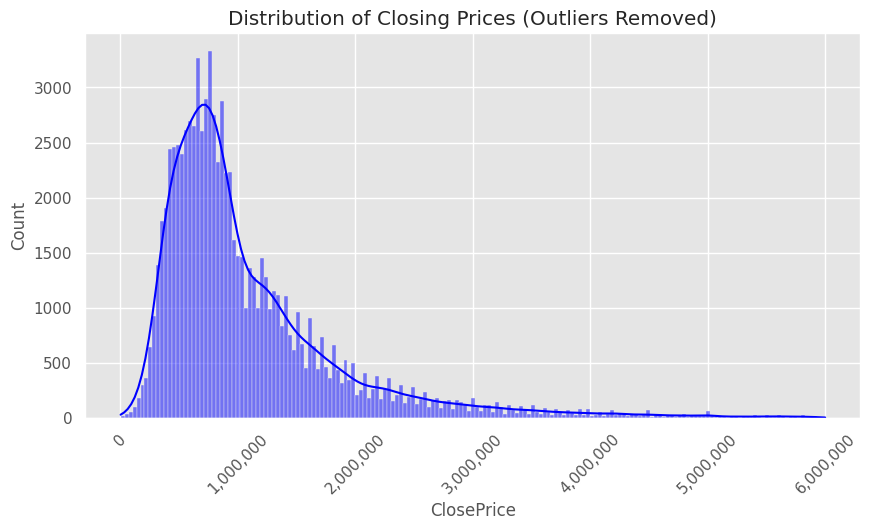

In [135]:
price_cutoff = rdf["ClosePrice"].quantile(0.99)
visual_df = rdf[rdf["ClosePrice"] < price_cutoff]

plt.figure(figsize=(10, 5))
sns.histplot(data=visual_df, x="ClosePrice", kde=True, color="blue")

ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))

plt.title("Distribution of Closing Prices (Outliers Removed)")
plt.xticks(rotation=45)
plt.show()


In [136]:
market_df = rdf[
    (rdf["ClosePrice"] < rdf["ClosePrice"].quantile(0.95))
    & (rdf["LivingArea"] < rdf["LivingArea"].quantile(0.95))
    & (rdf["LotSizeSquareFeet"] < rdf["LotSizeSquareFeet"].quantile(0.95))
].copy()

sns.set_theme(style="whitegrid")


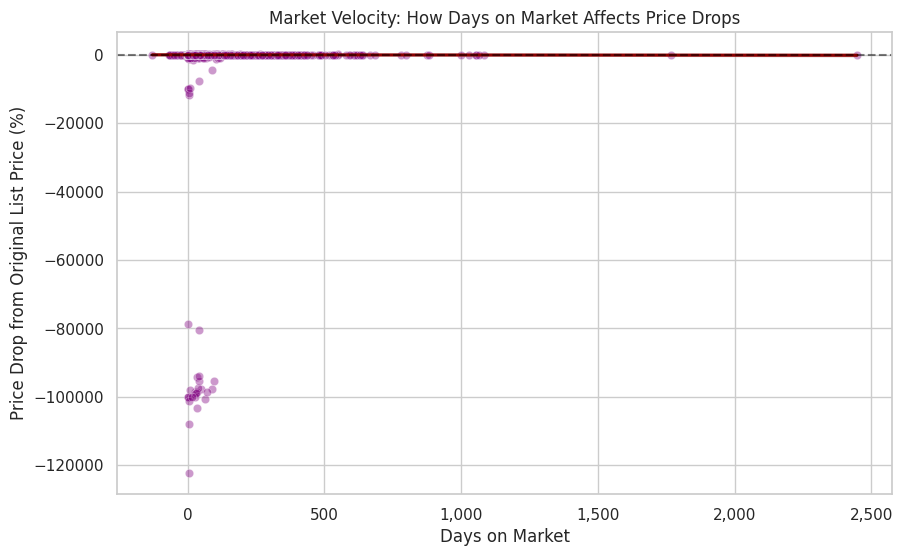

In [137]:
market_df["PriceDropPercent"] = (
    (market_df["OriginalListPrice"] - market_df["ClosePrice"])
    / market_df["OriginalListPrice"]
) * 100

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=market_df,
    x="DaysOnMarket",
    y="PriceDropPercent",
    alpha=0.4,
    color="purple",
)
sns.regplot(
    data=market_df,
    x="DaysOnMarket",
    y="PriceDropPercent",
    scatter=False,
    color="darkred",
)

plt.ticklabel_format(style="plain", axis="both")
ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))

plt.title("Market Velocity: How Days on Market Affects Price Drops")
plt.xlabel("Days on Market")
plt.ylabel("Price Drop from Original List Price (%)")
plt.axhline(0, color="black", linestyle="--", alpha=0.5)
plt.show()


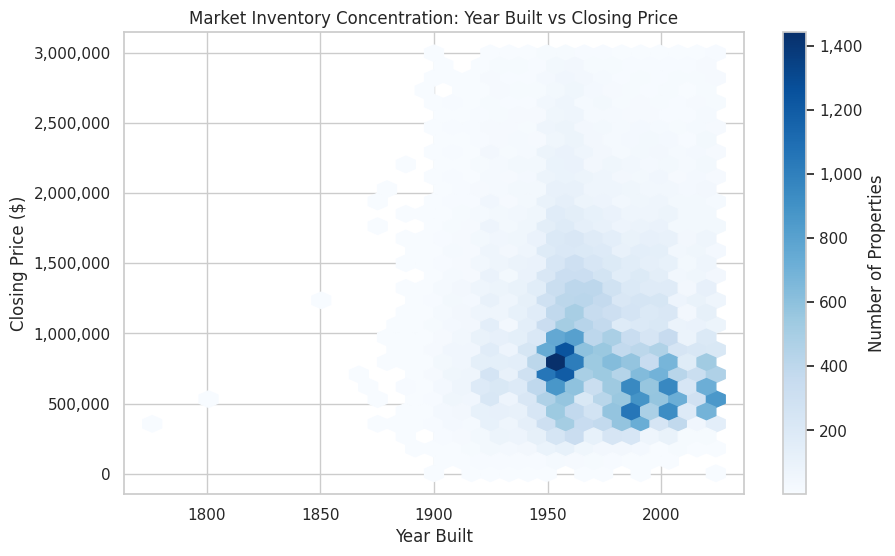

In [138]:
plt.figure(figsize=(10, 6))
hex_data = market_df.dropna(subset=["YearBuilt", "ClosePrice"])

hb = plt.hexbin(
    hex_data["YearBuilt"],
    hex_data["ClosePrice"],
    gridsize=30,
    cmap="Blues",
    mincnt=1,
)

plt.ticklabel_format(style="plain", axis="both")
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.0f}"))

cb = plt.colorbar(hb, label="Number of Properties")
cb.ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))

plt.title("Market Inventory Concentration: Year Built vs Closing Price")
plt.xlabel("Year Built")
plt.ylabel("Closing Price ($)")
plt.show()


In [139]:
fig = px.scatter_map(
    market_df,
    lat="Latitude",
    lon="Longitude",
    color="ClosePrice",
    size="LivingArea",
    color_continuous_scale=px.colors.sequential.Viridis,
    hover_data=["City", "ClosePrice", "BedroomsTotal", "DaysOnMarket"],
    zoom=9,
    title="Interactive Market Heatmap with Real Map Background",
)

fig.update_layout(
    coloraxis_colorbar=dict(
        title="Closing Price ($)",
        tickformat=",.0f",
    ),
    margin={"r": 0, "t": 40, "l": 0, "b": 0},
)

fig.show()

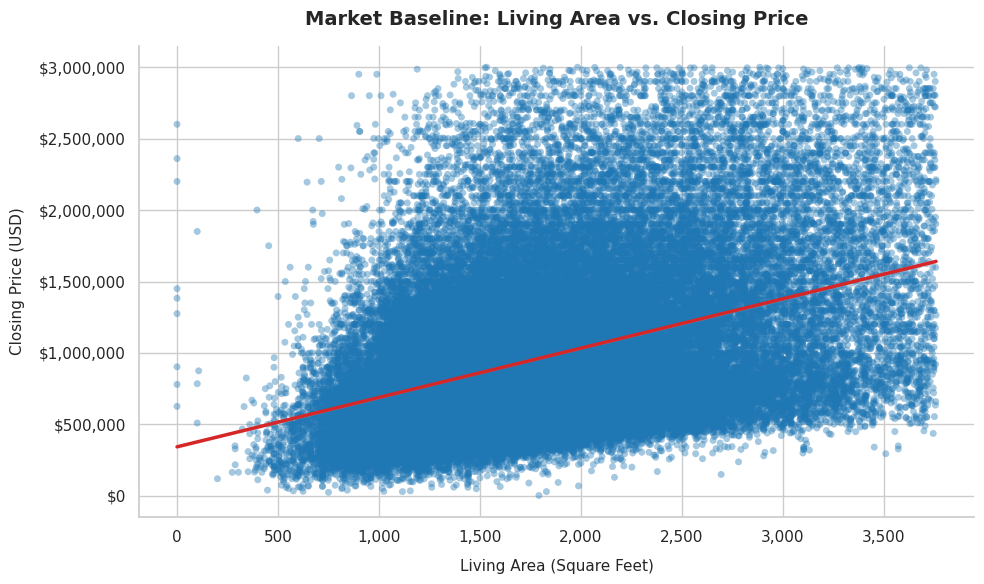

In [140]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=market_df,
    x="LivingArea",
    y="ClosePrice",
    scatter_kws={
        "alpha": 0.4,
        "s": 25,
        "color": "#1f77b4",
        "edgecolor": "none",
    },
    line_kws={
        "color": "#d62728",
        "linewidth": 2.5,
    },
    ci=95,
)

plt.ticklabel_format(style="plain", axis="both")

ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("${x:,.0f}"))
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))

plt.title(
    "Market Baseline: Living Area vs. Closing Price",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Living Area (Square Feet)", fontsize=11, labelpad=10)
plt.ylabel("Closing Price (USD)", fontsize=11, labelpad=10)

sns.despine()

plt.tight_layout()
plt.show()
